In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from datetime import datetime


In [17]:
data = pd.read_csv("cleaned_data_csv.csv")
data

,Kwh,name,datetime,temp,feelslike,dew,humidity,precip,snow,snowdepth,...,windspeed,winddir,sealevelpressure,cloudcover,visibility,solarradiation,solarenergy,uvindex,conditions,icon
0,0.0000,"Kozani, Greece",2022-01-01 00:00:00,6.0,4.4,2.0,75.51,0.0,0.0,0.0,...,7.6,240.0,1023.0,0.0,NaN,0.0,0.0,0.0,Clear,clear-night
1,0.0000,"Kozani, Greece",2022-01-01 01:00:00,6.0,5.0,2.0,75.51,0.0,0.0,0.0,...,5.4,298.1,1023.0,0.0,NaN,0.0,0.0,0.0,Clear,clear-night
2,0.0000,"Kozani, Greece",2022-01-01 02:00:00,4.9,3.2,2.0,81.61,0.0,NaN,0.0,...,7.6,301.0,1022.4,40.9,NaN,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night
3,0.0000,"Kozani, Greece",2022-01-01 03:00:00,4.0,4.0,1.0,80.80,0.0,NaN,0.0,...,3.6,294.8,1022.0,38.0,NaN,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night
4,0.0000,"Kozani, Greece",2022-01-01 04:00:00,3.0,1.6,2.0,93.14,0.0,NaN,0.0,...,5.4,292.3,1021.0,41.7,NaN,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21978,0.0592,"Kozani, Greece",2024-07-04 19:00:00,24.0,24.0,10.0,41.15,0.0,0.0,0.0,...,9.4,180.0,1010.0,79.3,NaN,207.0,0.7,2.0,Partially cloudy,partly-cloudy-day
21979,0.0085,"Kozani, Greece",2024-07-04 20:00:00,23.0,23.0,9.0,40.87,0.1,0.0,0.0,...,3.6,172.8,1010.0,81.7,NaN,103.0,0.4,1.0,"Rain, Partially cloudy",rain
21980,0.0000,"Kozani, Greece",2024-07-04 21:00:00,21.0,21.0,10.0,49.39,0.1,0.0,0.0,...,0.0,0.0,1011.0,63.7,NaN,9.0,0.0,0.0,"Rain, Partially cloudy",rain
21981,0.0000,"Kozani, Greece",2024-07-04 22:00:00,20.0,20.0,11.0,56.15,0.0,0.0,0.0,...,0.0,0.0,1012.0,65.5,NaN,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night


In [18]:
data["datetime"] = pd.to_datetime(data["datetime"])
data.set_index('datetime', inplace=True)

In [26]:
type(data.index)

pandas.core.indexes.datetimes.DatetimeIndex

In [27]:
decomposition = seasonal_decompose(data['temp'], model='additive', period=365)

In [28]:
decomposition

In [29]:
seasonal = decomposition.seasonal
trend = decomposition.trend
residual = decomposition.resid

In [30]:
seasonal, trend, residual

(datetime
 2022-01-01 00:00:00   -0.217319
 2022-01-01 01:00:00   -0.136706
 2022-01-01 02:00:00   -0.034059
 2022-01-01 03:00:00   -0.034849
 2022-01-01 04:00:00   -0.135545
                          ...   
 2024-07-04 19:00:00    0.431016
 2024-07-04 20:00:00    0.179379
 2024-07-04 21:00:00    0.090361
 2024-07-04 22:00:00    0.047060
 2024-07-04 23:00:00    0.425746
 Name: seasonal, Length: 21983, dtype: float64,
 datetime
 2022-01-01 00:00:00   NaN
 2022-01-01 01:00:00   NaN
 2022-01-01 02:00:00   NaN
 2022-01-01 03:00:00   NaN
 2022-01-01 04:00:00   NaN
                        ..
 2024-07-04 19:00:00   NaN
 2024-07-04 20:00:00   NaN
 2024-07-04 21:00:00   NaN
 2024-07-04 22:00:00   NaN
 2024-07-04 23:00:00   NaN
 Name: trend, Length: 21983, dtype: float64,
 datetime
 2022-01-01 00:00:00   NaN
 2022-01-01 01:00:00   NaN
 2022-01-01 02:00:00   NaN
 2022-01-01 03:00:00   NaN
 2022-01-01 04:00:00   NaN
                        ..
 2024-07-04 19:00:00   NaN
 2024-07-04 20:00:00   NaN
 

<Axes: xlabel='datetime'>

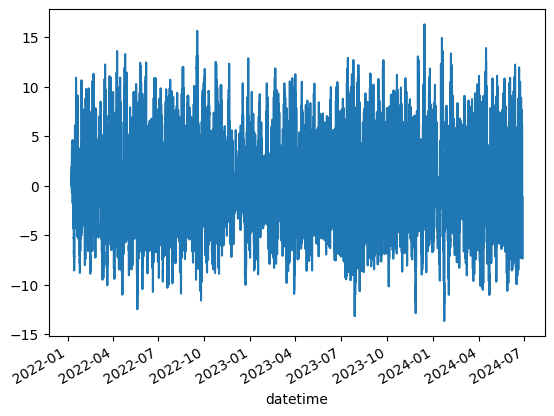

In [36]:
residual.plot()